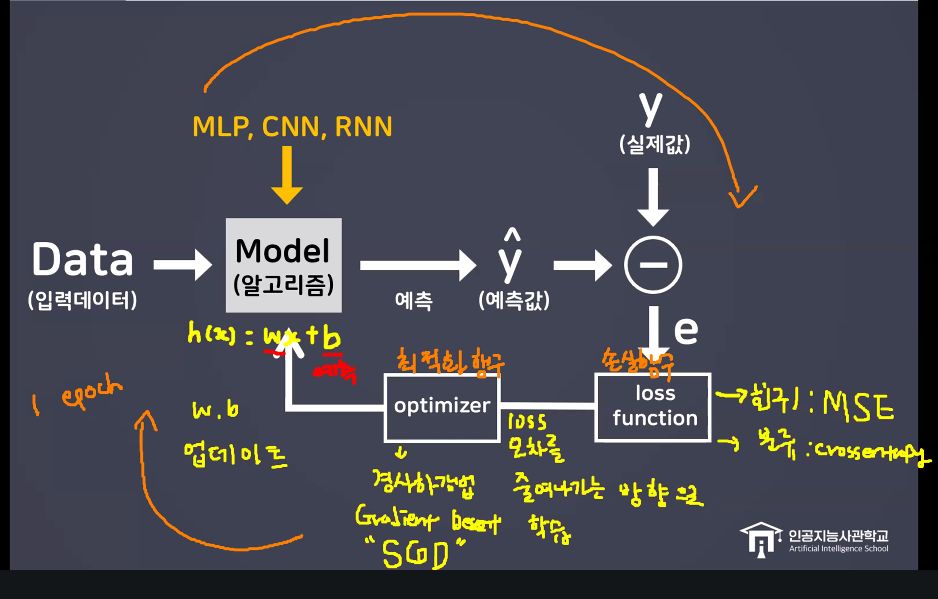 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
x = np.array([2, 4, 6, 8])
# x = np.array([[2,0],[4,4],[6,2],[8,3]])
y = np.array([81, 93, 91, 97])

In [ ]:
model = Sequential([
    Input(shape=(1,)),  # 입력 특성 (feature)이 1개
    Dense(1,activation="linear")
])

model.compile(optimizer="sgd",loss="mse")

model.fit(x,y,epochs=1000) 

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 6782.5942
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1834.2776
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1102.1125
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 989.2299
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 967.3388
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 958.8467
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 952.3568
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 946.1946
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 940.1145
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 934.0800
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 928.0854
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 922.1296
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 916.2128
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 910.3340
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


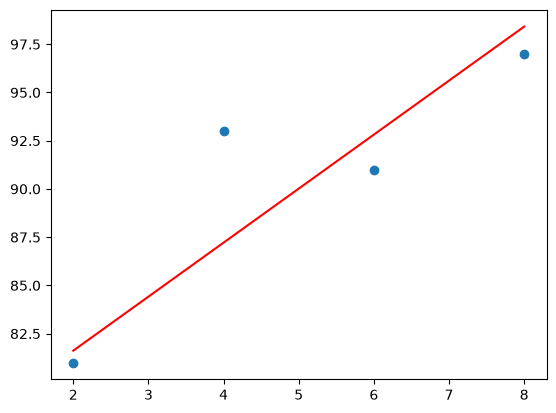

In [8]:
plt.scatter(x,y)
plt.plot(x, model.predict(x),"r")

In [9]:
weights, bias = model.layers[0].get_weights()

print(weights)
print(bias)

[[2.7995589]]
[76.018845]


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [12]:
# 예측
pred = model.predict(np.array([10,11]))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[104.014435]
 [106.813995]]


In [13]:
# 경사하강법 직접 구현

# 오차 계산 → 기울기 계산 → 가중치 수정 → 반복

w = 10
lr = 0.1

for epoch in range(20):

    loss = (w-3)**2    
    grad = 2 * (w-3) # 위의 미분
    
    #새 가중치 = 기존 가중치 - 학습률×기울기
    w = w - lr * grad 

    print(epoch,round(w,3),round(loss,3))

0 8.6 49
1 7.48 31.36
2 6.584 20.07
3 5.867 12.845
4 5.294 8.221
5 4.835 5.261
6 4.468 3.367
7 4.174 2.155
8 3.94 1.379
9 3.752 0.883
10 3.601 0.565
11 3.481 0.362
12 3.385 0.231
13 3.308 0.148
14 3.246 0.095
15 3.197 0.061
16 3.158 0.039
17 3.126 0.025
18 3.101 0.016
19 3.081 0.01


In [26]:
# 문제  자동차 속도와 연비

# 데이터

x = np.array([
    40,
    60,
    80,
    100,
    120
])

y = np.array([
    25,
    22,
    19,
    16,
    13
])

# 해야 할 일
# 모델 생성
# 학습 수행
# 속도 90km일 때 연비 예측

model = Sequential([
    Input(shape=(1,)),  # 컬럼 (feature) 갯수 , Input (입력층)
    Dense(1,activation="linear")  # Dense는 layer (출력층)
])

model.compile(optimizer="adam",loss="mse")  # optimizer : 오차를 줄임 ,sgd를 넣고 돌리면 loss 값이 커지고 inf(무한)가 뜨는데 이것이 발산 이라 함

model.fit(x,y,epochs=2000,verbose=1)  # verbose=1은 모델 학습 중 epoch 진행 상황과 loss 값을 화면에 보여주는 옵션


Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - loss: 4723.4692
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 4711.8110
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4700.1675
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 4688.5400
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 4676.9277
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 4665.3306
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 4653.7500
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4642.1865
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4630.6382
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4619.1079
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4607.5947
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 4596.0986
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 4584.6201
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 4573.1582
Epoch 15/2000
1/1 ━━━━━━━━━━

In [27]:
# 가중치 바이어스 확인 
weights, bias = model.layers[0].get_weights()

print(weights,bias)

# 예측
pred = model.predict(np.array([[90]]))
print(pred)

[[0.18149342]] [0.9382492]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[17.272657]]
